# IEEE CIS Fraud Detection - Exploratory Data Analysis

In [2]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

# system
import os
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parents[2]))  # workaround to resolve my helper module above

# dataframe
import polars as pl
import polars.selectors as cs

# modules
from modules.plotting import *
from modules.polars_helpers import *

# stats
from scipy.stats import pearsonr

parent_dir = Path.cwd().parent

DATA_PATH = str(parent_dir / "data") + "/"
print(DATA_PATH)

RANDOM_SEED = 42

/Users/luiscruz/Desktop/kaggle_challenges/classification/ieee-fraud-detection/data/


In [3]:
train_transaction = pl.read_csv(DATA_PATH + "train_transaction.csv")
train_identity = pl.read_csv(DATA_PATH + "train_identity.csv")

Transactions -
- TransactionDT: timedelta from a given reference datetime (not an actual timestamp)
- TransactionAMT: transaction payment amount in USD
- ProductCD: product code, the product for each transaction
- card1 - card6: payment card information, such as card type, card category, issue bank, country, etc.
- addr: address
- dist: distance
- P_ and (R__) emaildomain: purchaser and recipient email domain
- C1-C14: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked.
- D1-D15: timedelta, such as days between previous transaction, etc.
- M1-M9: match, such as names on card and address, etc.
- Vxxx: Vesta engineered rich features, including ranking, counting, and other entity relations.
Categorical Features:
- ProductCD
- card1 - card6
- addr1, addr2
- P_emaildomain
- R_emaildomain
- M1 - M9

Identity -
Variables in this table are identity information – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions.
They're collected by Vesta’s fraud protection system and digital security partners.
(The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement)

Categorical Features:
- DeviceType
- DeviceInfo
- id_12 - id_38

In [5]:
train_identity.schema

Schema([('TransactionID', Int64),
        ('id_01', Float64),
        ('id_02', Float64),
        ('id_03', Float64),
        ('id_04', Float64),
        ('id_05', Float64),
        ('id_06', Float64),
        ('id_07', Float64),
        ('id_08', Float64),
        ('id_09', Float64),
        ('id_10', Float64),
        ('id_11', Float64),
        ('id_12', String),
        ('id_13', Float64),
        ('id_14', Float64),
        ('id_15', String),
        ('id_16', String),
        ('id_17', Float64),
        ('id_18', Float64),
        ('id_19', Float64),
        ('id_20', Float64),
        ('id_21', Float64),
        ('id_22', Float64),
        ('id_23', String),
        ('id_24', Float64),
        ('id_25', Float64),
        ('id_26', Float64),
        ('id_27', String),
        ('id_28', String),
        ('id_29', String),
        ('id_30', String),
        ('id_31', String),
        ('id_32', Float64),
        ('id_33', String),
        ('id_34', String),
        ('id_35', String)

In [6]:
train_identity

TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str
2987004,0.0,70787.0,null,null,null,null,null,null,null,null,100.0,"""NotFound""",null,-480.0,"""New""","""NotFound""",166.0,null,542.0,144.0,null,null,null,null,null,null,null,"""New""","""NotFound""","""Android 7.0""","""samsung browser 6.2""",32.0,"""2220x1080""","""match_status:2""","""T""","""F""","""T""","""T""","""mobile""","""SAMSUNG SM-G892A Build/NRD90M"""
2987008,-5.0,98945.0,null,null,0.0,-5.0,null,null,null,null,100.0,"""NotFound""",49.0,-300.0,"""New""","""NotFound""",166.0,null,621.0,500.0,null,null,null,null,null,null,null,"""New""","""NotFound""","""iOS 11.1.2""","""mobile safari 11.0""",32.0,"""1334x750""","""match_status:1""","""T""","""F""","""F""","""T""","""mobile""","""iOS Device"""
2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,null,null,0.0,0.0,100.0,"""NotFound""",52.0,null,"""Found""","""Found""",121.0,null,410.0,142.0,null,null,null,null,null,null,null,"""Found""","""Found""",null,"""chrome 62.0""",null,null,null,"""F""","""F""","""T""","""T""","""desktop""","""Windows"""
2987011,-5.0,221832.0,null,null,0.0,-6.0,null,null,null,null,100.0,"""NotFound""",52.0,null,"""New""","""NotFound""",225.0,null,176.0,507.0,null,null,null,null,null,null,null,"""New""","""NotFound""",null,"""chrome 62.0""",null,null,null,"""F""","""F""","""T""","""T""","""desktop""",null
2987016,0.0,7460.0,0.0,0.0,1.0,0.0,null,null,0.0,0.0,100.0,"""NotFound""",null,-300.0,"""Found""","""Found""",166.0,15.0,529.0,575.0,null,null,null,null,null,null,null,"""Found""","""Found""","""Mac OS X 10_11_6""","""chrome 62.0""",24.0,"""1280x800""","""match_status:2""","""T""","""F""","""T""","""T""","""desktop""","""MacOS"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,null,null,0.0,0.0,100.0,"""NotFound""",27.0,null,"""Found""","""Found""",225.0,null,427.0,139.0,null,null,null,null,null,null,null,"""Found""","""Found""",null,"""chrome 66.0 for android""",null,null,null,"""F""","""F""","""T""","""F""","""mobile""","""F3111 Build/33.3.A.1.97"""
3577526,-5.0,172059.0,null,null,1.0,-5.0,null,null,null,null,100.0,"""NotFound""",27.0,-300.0,"""New""","""NotFound""",166.0,15.0,352.0,333.0,null,null,null,null,null,null,null,"""New""","""NotFound""","""Android 7.1.1""","""chrome 55.0 for android""",32.0,"""855x480""","""match_status:2""","""T""","""F""","""T""","""F""","""mobile""","""A574BL Build/NMF26F"""
3577529,-20.0,632381.0,null,null,-1.0,-36.0,null,null,null,null,100.0,"""NotFound""",27.0,null,"""New""","""NotFound""",225.0,27.0,567.0,411.0,null,null,null,null,null,null,null,"""New""","""NotFound""",null,"""chrome 65.0 for android""",null,null,null,"""F""","""F""","""T""","""F""","""mobile""","""Moto E (4) Plus Build/NMA26.42…"


In [7]:
train_identity.null_count()

TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,3361,77909,77909,7368,7368,139078,139078,69307,69307,3255,0,16913,64189,3248,14893,4864,99120,4915,4972,139074,139064,139064,139486,139101,139070,139064,3255,3255,66668,3951,66647,70944,66428,3248,3248,3248,3248,3423,25567


In [9]:
train_transaction.schema

Schema([('TransactionID', Int64),
        ('isFraud', Int64),
        ('TransactionDT', Int64),
        ('TransactionAmt', Float64),
        ('ProductCD', String),
        ('card1', Int64),
        ('card2', Float64),
        ('card3', Float64),
        ('card4', String),
        ('card5', Float64),
        ('card6', String),
        ('addr1', Float64),
        ('addr2', Float64),
        ('dist1', Float64),
        ('dist2', Float64),
        ('P_emaildomain', String),
        ('R_emaildomain', String),
        ('C1', Float64),
        ('C2', Float64),
        ('C3', Float64),
        ('C4', Float64),
        ('C5', Float64),
        ('C6', Float64),
        ('C7', Float64),
        ('C8', Float64),
        ('C9', Float64),
        ('C10', Float64),
        ('C11', Float64),
        ('C12', Float64),
        ('C13', Float64),
        ('C14', Float64),
        ('D1', Float64),
        ('D2', Float64),
        ('D3', Float64),
        ('D4', Float64),
        ('D5', Float64),
        ('

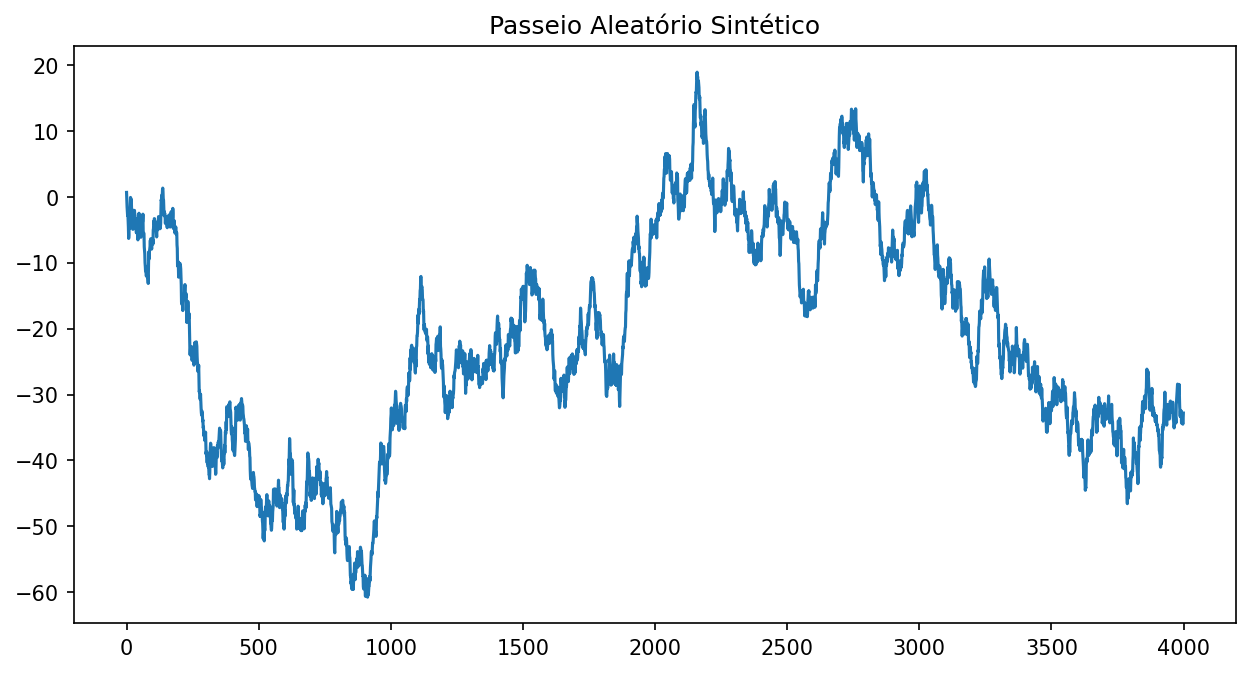

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_steps = 4000  # Number of steps in the random walk
step_size = 1    # Fixed step size in x

# Generate x: always moving forward
x = np.arange(0, num_steps * step_size, step_size)

# Generate y: cumulative sum of random steps
y_steps = np.random.normal(loc=0, scale=1, size=num_steps)  # Gaussian steps
y = np.cumsum(y_steps)  # Cumulative sum for the random walk in y

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.title('Passeio Aleatório Sintético')
# plt.grid(True)
plt.show()
